# Caso TakeHome Lezione 16: UK LDI 2022 — Buffer di liquidità, margin call e non anticipatività

## 1. Contesto del Caso e Domanda Quantitativa

### Contesto del Caso
Nel settembre 2022, il forte e repentino aumento dei rendimenti dei titoli di Stato britannici (gilt) ha generato imponenti margin call sulle posizioni in derivati e sulle operazioni repo utilizzate dalle strategie *Liability Driven Investment* (LDI) dei fondi pensione a prestazione definita. In presenza di cuscinetti di liquidità insufficienti, gli operatori hanno dovuto mobilitare risorse aggiuntive ed effettuare un drastico *deleveraging* (riduzione delle posizioni) in un contesto di incertezza e informazione progressiva. Il presente caso analizza in forma stilizzata un problema di programmazione stocastica multistadio in cui il decisore sceglie dapprima la composizione iniziale dell'attivo e successivamente adatta le proprie scelte in due stadi aleatori successivi, nel rigoroso rispetto dei vincoli di non anticipatività.

### Domanda Quantitativa
Quale combinazione iniziale tra buffer di liquidità ed esposizione LDI massimizza il risultato economico atteso quando le margin call si manifestano progressivamente e le decisioni di adattamento devono rispettare l'informazione effettivamente disponibile? Quanto valore apparente si ottiene violando la non anticipatività e quanto varrebbe conoscere fin dall'inizio l'intero percorso futuro degli shock?

### Variabile Finale e Struttura Informativa
- **Variabile finale:** Risultato economico atteso complessivo espresso come rendimento iniziale netto dei costi di aggiustamento, mobilitazione della liquidità e deleveraging lungo l'albero degli scenari.
- **Struttura informativa:** 

$$
(b,h) \longrightarrow \{M,S\} \longrightarrow (y_n,u_n,g_n) \longrightarrow \{MR,MP,SR,SS\} \longrightarrow (z_\ell,v_\ell,G_\ell)
$$

Le decisioni iniziali $(b,h)$ precedono ogni osservazione. Le decisioni intermedie ai nodi $n \in \{M,S\}$ dipendono unicamente dallo shock del primo stadio. Le decisioni terminali dipendono dall'intero percorso finale $\ell \in \{MR,MP,SR,SS\}$.

---

## 2. Quantità da Calcolare

### 2.1 Soluzione Multistadio Corretta
1. Buffer di liquidità iniziale ottimo: $b^{MS}$
2. Esposizione LDI iniziale ottima: $h^{MS}$
3. Decisioni ai nodi intermedi $n \in \{M,S\}$:
   - Deleveraging intermedio: $y_M, y_S$
   - Liquidità aggiuntiva mobilitata: $u_M, u_S$
   - Liquidità residua dopo la prima margin call: $g_M, g_S$
4. Decisioni terminali per ciascun percorso $\ell \in \{MR, MP, SR, SS\}$:
   - Ulteriore deleveraging terminale: $z_\ell$
   - Ulteriore liquidità aggiuntiva mobilitata: $v_\ell$
   - Liquidità residua terminale: $G_\ell$
5. Valore ottimo della funzione obiettivo multistadio: $z^{MS}$

### 2.2 Rilassamento Anticipativo
1. Valore ottimo con violazione della non anticipatività: $z^{AR}$
2. Decisioni intermedie rese (illegittimamente) specifiche del singolo percorso terminale: $(y_\ell, u_\ell, g_\ell)$
3. Diagnostica di vantaggio artificiale da anticipatività:

$$
\Delta_{NA} = z^{AR} - z^{MS}
$$

### 2.3 Wait-and-See ed EVPI
1. Valori ottimi dei problemi deterministici separati per ciascun percorso: $z_\ell^{WS}$
2. Valore atteso con informazione perfetta (Wait-and-See):

$$
z^{WS} = \sum_{\ell} p_\ell z_\ell^{WS}
$$

3. Valore Atteso dell'Informazione Perfetta:

$$
EVPI = z^{WS} - z^{MS}
$$

---

## 3. Output Richiesti

### 3.1 Tabelle
- **Tabella 1 — Albero degli scenari e parametri:** Nodi, percorsi, probabilità dei nodi, probabilità condizionate, probabilità dei percorsi, coefficienti di margin call ($a_n, \beta_\ell$), costi di deleveraging ($\lambda_n, \mu_\ell$), costi di liquidità ($\kappa_n, \eta_\ell$) e limiti operativi.
- **Tabella 2 — Soluzione multistadio:** Valori di $b^{MS}$ e $h^{MS}$; decisioni ai nodi $M$ e $S$; decisioni terminali sui quattro percorsi; liquidità residua e costi di adattamento sostenuti.
- **Tabella 3 — Verifica della non anticipatività:** Confronto esplicito delle decisioni intermedie sui percorsi con storia comune ($MR \leftrightarrow MP$ e $SR \leftrightarrow SS$).
- **Tabella 4 — Confronto dei benchmark informativi:** Confronto strutturato tra modello multistadio corretto, rilassamento anticipativo e wait-and-see (informazione disponibile, decisioni iniziali, principali decisioni di adattamento, valore obiettivo).
- **Tabella 5 — Valore dell'informazione:** Sintesi delle metriche $z^{MS}$, $z^{AR}$, $\Delta_{NA}$, $z^{WS}$ ed $EVPI$.

### 3.2 Grafici
- **Figura 1:** Rappresentazione dell'albero degli scenari con probabilità e coefficienti di margin call.
- **Figura 2:** Grafico del deleveraging intermedio e terminale nei diversi nodi e percorsi.
- **Figura 3:** Grafico di confronto tra modello multistadio corretto e rilassamento anticipativo, evidenziando le decisioni che differiscono quando la non anticipatività viene violata.

---

## 4. Controlli Richiesti

Il modello e il notebook devono verificare esplicitamente le seguenti 19 condizioni:

1. Probabilità nodi iniziali: $p_M + p_S = 1$
2. Somma ad uno delle probabilità condizionate per ogni nodo
3. Somma ad uno delle probabilità dei quattro percorsi: $\sum_\ell p_\ell = 1$
4. Vincolo risorse iniziali: $b + h = 100$
5. Vincolo copertura minima passività: $h \geq 50$
6. Limiti operativi deleveraging intermedio: $0 \leq y_n \leq 25$
7. Limiti operativi liquidità aggiuntiva intermedia: $0 \leq u_n \leq 4$
8. Limiti operativi deleveraging terminale: $0 \leq z_\ell \leq 10$
9. Limiti operativi liquidità aggiuntiva terminale: $0 \leq v_\ell \leq 4$
10. Capacità massima deleveraging complessivo per percorso: $y_{n(\ell)} + z_\ell \leq 40$
11. Bilancio di liquidità al nodo intermedio: $b + u_n + y_n = a_n h + g_n$ per ogni $n \in \{M, S\}$
12. Bilancio di liquidità terminale: $g_{n(\ell)} + v_\ell + z_\ell = \beta_\ell (h - y_{n(\ell)}) + G_\ell$ per ogni percorso $\ell$
13. Rispetto dei vincoli di non negatività per tutte le variabili
14. Raggiungimento dello stato di ottimalità del solver
15. Rispetto dei vincoli di non anticipatività nel modello multistadio corretto
16. Unicità delle decisioni iniziali $b$ e $h$ tra i percorsi nel rilassamento anticipativo
17. Gerarchia tra rilassamento e multistadio: $z^{AR} \geq z^{MS}$
18. Gerarchia tra wait-and-see e rilassamento: $z^{WS} \geq z^{AR}$
19. Non negatività dell'EVPI: $EVPI \geq 0$

---

## 5. Vincolante della Scheda Caso

La Scheda Caso costituisce la **specifica vincolante del lavoro** e non può essere modificata durante lo svolgimento. Parametri, formule, vincoli, sequenza temporale e controlli definiti nella traccia rappresentano l'unico riferimento teorico e computazionale del notebook.

# Fase 3 — Flusso Logico-Teorico Risolutivo del Caso

I sette passaggi teorici di seguito riassunti costituiscono l'ossatura concettuale del problema e definiscono la sequenza delle operazioni analitiche necessarie per pervenire alla soluzione ottimale e ai relativi benchmark informativi.

| Passo | Finalità risolutiva | Formula, definizione, proprietà o teorema | Applicazione nel caso | Output o controllo collegato |
|---:|---|---|---|---|
| **1** | **Inizializzazione dello spazio delle decisioni e delle risorse** | Vincolo di bilancio iniziale e condizioni di ammissibilità:<br>$b + h = A_0 = 100$<br>$h \geq 50,\quad b \geq 0,\quad h \geq 0$ | Definizione del dominio di scelta ammissibile per l'allocazione primaria tra buffer di liquidità $b$ ed esposizione LDI $h$. | Controllo vincoli risorse iniziali: $b+h=100$, $h\geq50$, $b,h\geq0$. |
| **2** | **Formalizzazione della struttura informativa e probabilistica** | Proprietà della misura di probabilità su albero delle decisioni multistadio:<br>$p_M + p_S = 1$<br>$\mathbb{P}(MR\mid M)+\mathbb{P}(MP\mid M)=1$<br>$\mathbb{P}(SR\mid S)+\mathbb{P}(SS\mid S)=1$<br>$p_\ell = p_{n(\ell)} \cdot \mathbb{P}(\ell \mid n(\ell))$, $\sum_{\ell} p_\ell = 1$ | Caratterizzazione stocastica dell'albero a due stadi aleatori con 2 nodi intermedi ($M, S$) e 4 percorsi terminali ($MR, MP, SR, SS$). | **Tabella 1 — Albero degli scenari e parametri**.<br>Controlli su somme delle probabilità nodali, condizionate e di percorso. |
| **3** | **Formalizzazione delle dinamiche di bilancio di liquidità e vincoli operativi** | Equazioni di bilancio di liquidità al primo stadio aleatorio ($n \in \{M,S\}$):<br>$b + u_n + y_n = a_n h + g_n$<br>ed al secondo stadio terminale ($\ell \in \{MR,MP,SR,SS\}$):<br>$g_{n(\ell)} + v_\ell + z_\ell = \beta_\ell (h - y_{n(\ell)}) + G_\ell$<br><br>Limiti operativi:<br>$0 \leq y_n \leq 25,\quad 0 \leq u_n \leq 4$<br>$0 \leq z_\ell \leq 10,\quad 0 \leq v_\ell \leq 4$<br>$y_{n(\ell)} + z_\ell \leq 40,\quad g_n, G_\ell \ge 0$ | Modellizzazione delle risposte alle margin call nei nodi intermedi e nei percorsi terminali via deleveraging ($y_n, z_\ell$), liquidità aggiuntiva ($u_n, v_\ell$) e conservazione della liquidità residua ($g_n, G_\ell$). | Controlli di bilancio al nodo intermedio (11) e terminale (12); controlli sui limiti operativi di deleveraging e liquidità aggiuntiva (6-10, 13). |
| **4** | **Formalizzazione della Funzione Obiettivo Multistadio** | Massimizzazione del rendimento atteso netto dai costi attesi di adattamento:<br>$\max z^{MS} = r_b b + r_h h - \sum_{n} p_n (\lambda_n y_n + \kappa_n u_n) - \sum_{\ell} p_\ell (\mu_\ell z_\ell + \eta_\ell v_\ell)$<br>con $r_b=0.010, r_h=0.045$. | Determinazione del piano di decisioni ottimo ($b^{MS}, h^{MS}, y_n, u_n, g_n, z_\ell, v_\ell, G_\ell$) che massimizza il risultato economico atteso rispettando la struttura informativa. | **Tabella 2 — Soluzione multistadio**.<br>Controllo di ottimalità del solver e non negatività. |
| **5** | **Imposizione e verifica dei vincoli di Non Anticipatività** | Principio di Non Anticipatività (misurabilità delle decisioni rispetto alla filtrazione informativa):<br>$\begin{cases} y_{MR} = y_{MP} = y_M \\ u_{MR} = u_{MP} = u_M \\ g_{MR} = g_{MP} = g_M \end{cases}$ e $\begin{cases} y_{SR} = y_{SS} = y_S \\ u_{SR} = u_{SS} = u_S \\ g_{SR} = g_{SS} = g_S \end{cases}$ | Garanzia che le decisioni intermedie al tempo $t=1$ dipendano unicamente dallo shock osservato al nodo $n \in \{M,S\}$ e non dall'evoluzione futura del ramo. | **Tabella 3 — Verifica della non anticipatività**.<br>Controllo rispetto vincoli di non anticipatività (15). |
| **6** | **Formalizzazione del Rilassamento Anticipativo ($\Delta_{NA}$)** | Formulazione del modello con violazione della non anticipatività (decisioni intermedie libere per percorso $\ell$):<br>$\max z^{AR}$ s.t. $b, h$ unici ma $(y_\ell, u_\ell, g_\ell)$ specifici per percorso.<br><br>Diagnostica di vantaggio artificiale:<br>$\Delta_{NA} = z^{AR} - z^{MS} \geq 0$ | Misurazione del guadagno fittizio ottenibile se il decisore potesse anticipare illegittimamente lo sviluppo terminale dello stress già al nodo intermedio. | Controllo unicità decisioni iniziali (16) e gerarchia $z^{AR} \geq z^{MS}$ (17). |
| **7** | **Formalizzazione dei benchmark Wait-and-See, EVPI e Gerarchia Informativa** | Problemi deterministici per percorso $\ell$: $z_\ell^{WS}$.<br>Valore atteso con informazione perfetta:<br>$z^{WS} = \sum_{\ell} p_\ell z_\ell^{WS}$<br><br>Valore Atteso dell'Informazione Perfetta:<br>$EVPI = z^{WS} - z^{MS} \geq 0$<br><br>Teorema di Gerarchia Informativa:<br>$z^{MS} \leq z^{AR} \leq z^{WS}$ | Valutazione del massimo prezzo economico che il decisore sarebbe disposto a pagare per conoscere a priori l'intero percorso futuro degli shock. | **Tabella 4 — Confronto dei benchmark informativi**.<br>**Tabella 5 — Valore dell'informazione**.<br>Controlli $z^{WS} \geq z^{AR}$ (18) ed $EVPI \geq 0$ (19). |

# Fase 5 — Scomposizione del Problema in Tappe Input-Output

Di seguito viene presentata la scomposizione operativa del lavoro computazionale in tappe sequenziali. Ogni tappa definisce chiaramente gli input richiesti, le operazioni da eseguire, gli output prodotti, i controlli di validazione e l'impiego degli output nelle tappe successive, garantendo la continuità del flusso di calcolo e il rispetto rigoroso della Scheda Caso.

| Tappa | Input | Operazione | Output | Controllo | Uso successivo |
|---:|---|---|---|---|---|
| **1** | - Parametri esogeni della Scheda Caso<br>- Probabilità nodi ($p_M, p_S$) e condizionate<br>- Coeff. margin call ($a_n, \beta_\ell$)<br>- Costi ($\lambda_n, \kappa_n, \mu_\ell, \eta_\ell$)<br>- Limiti operativi | Inizializzazione della struttura dell'albero stocastico a due stadi. Calcolo delle probabilità congiunte dei percorsi $p_\ell = p_{n(\ell)} \cdot \mathbb{P}(\ell \mid n(\ell))$. Rappresentazione tabellare e grafica dell'albero. | - **Tabella 1** (Albero scenari e parametri)<br>- **Figura 1** (Grafo albero degli scenari)<br>- Oggetti e vettori parametri in Python | Controlli 1-3:<br>- $p_M + p_S = 1$<br>- $\sum \mathbb{P}(\cdot \mid n) = 1$<br>- $\sum_\ell p_\ell = 1$ | Input per la costruzione delle equazioni di bilancio e delle funzioni obiettivo nelle Tappe 2, 4 e 5. |
| **2** | - Parametri e probabilità validati (Tappa 1)<br>- Specifiche del problema multistadio stocastico $z^{MS}$ | Formulazione e risoluzione del problema di programmazione lineare multistadio corretto con vincoli espliciti di non anticipatività incorporati nella struttura dei nodi. | - Oggetto modello e vettori di decisione ottimi:<br>  $b^{MS}, h^{MS}, y_n, u_n, g_n, z_\ell, v_\ell, G_\ell$<br>- Valore ottimo $z^{MS}$ | Controllo 14:<br>- Stato di ottimalità del solver (`OptimizationStatus.OPTIMAL`) | Input per i controlli di ammissibilità (Tappa 3) e per il confronto con i benchmark informativi (Tappe 4, 5 e 6). |
| **3** | - Soluzione ottima $z^{MS}$ e vettori di decisione (Tappa 2)<br>- Parametri del problema (Tappa 1) | Esecuzione dei controlli numerici e logici di ammissibilità bilancio, limiti operativi e verifica esplicita della non anticipatività. | - Esito positivo dei controlli numerici (15 controlli specifici su 19 complessivi) | Controlli 4-13, 15:<br>- $b+h=100$, $h\ge50$<br>- Limiti su $y_n, u_n, z_\ell, v_\ell$<br>- Deleveraging tot $\le 40$<br>- Bilanci nodi/terminali<br>- Non negatività<br>- $y_{MR}=y_{MP}=y_M$, etc. | Validazione della correttezza concettuale e numerica della soluzione $z^{MS}$ prima del confronto con $z^{AR}$ e $z^{WS}$. |
| **4** | - Parametri e probabilità validati (Tappa 1)<br>- Struttura decisionale slegata dai vincoli di non anticipatività | Formulazione e risoluzione del modello di Rilassamento Anticipativo $z^{AR}$ (decisioni intermedie $y_\ell, u_\ell, g_\ell$ specifiche per percorso $\ell$) e calcolo della diagnostica $\Delta_{NA} = z^{AR} - z^{MS}$. | - Vettori ottimi del rilassamento<br>- Valore ottimo $z^{AR}$<br>- Diagnostica $\Delta_{NA}$ | Controlli 14, 16, 17:<br>- Ottimalità solver<br>- Unicità $b, h$ tra percorsi<br>- $z^{AR} \ge z^{MS}$ | Input per le Tabelle 4 e 5, Figura 3 e analisi critica dell'impatto dell'anticipatività (Tappa 6). |
| **5** | - Parametri percorsi $\ell \in \{MR, MP, SR, SS\}$ (Tappa 1)<br>- Soluzioni $z^{MS}$ (Tappa 2) e $z^{AR}$ (Tappa 4) | Risoluzione dei 4 problemi deterministici separati per percorso $z_\ell^{WS}$, calcolo della media pesata $z^{WS} = \sum_\ell p_\ell z_\ell^{WS}$ e determinazione dell'EVPI $= z^{WS} - z^{MS}$. | - Valori deterministici $z_\ell^{WS}$<br>- Valore atteso $z^{WS}$<br>- Valore $EVPI$ | Controlli 18-19:<br>- $z^{WS} \ge z^{AR}$<br>- $EVPI \ge 0$<br>Verifica gerarchia:<br>$z^{MS} \le z^{AR} \le z^{WS}$ | Input per la costruzione delle Tabelle 4 e 5 e per l'interpretazione del valore dell'informazione (Tappa 6). |
| **6** | - Output numerici di tutte le tappe precedenti (Tappe 1-5) | Popolamento delle tabelle di sintesi, generazione dei grafici comparativi e stesura del commento economico-finanziario conclusivo su buffer, deleveraging e vincoli informativi. | - **Tabella 2** (Soluzione MS)<br>- **Tabella 3** (Verifica NA)<br>- **Tabella 4** (Confronto benchmark)<br>- **Tabella 5** (Valore informazione)<br>- **Figura 2** (Deleveraging)<br>- **Figura 3** (MS vs AR)<br>- Commento critico finale | Verifica di completezza e coerenza di tutti i 19 controlli della Scheda Caso e corrispondenza con gli output richiesti. | Chiusura del Notebook computazionale e base per la redazione del Tracciato IA (Fasi 8 e 9). |

# Tappa 1 — Ricostruzione dell'Albero degli Scenari, Inizializzazione dei Parametri e Controlli Probabilistici

In questa prima tappa computationalmente operativa vengono definiti e strutturati i parametri esogeni stabiliti dalla Scheda Caso vincolante.

In particolare, la tappa provvede a:
1. Inizializzare le risorse iniziali ($A_0 = 100$), i rendimenti base ($r_b, r_h$) e le probabilit\`a dei nodi e condizionate.
2. Calcolare le probabilit\`a congiunte dei quattro percorsi terminali $\ell \in \{MR, MP, SR, SS\}$ attraverso la relazione:
   
   $$p_\ell = p_{n(\ell)} \cdot \mathbb{P}(\ell \mid n(\ell))$$

3. Definire i vettori dei coefficienti di margin call ($a_n, \beta_\ell$), dei costi unitari di deleveraging ($\lambda_n, \mu_\ell$) e di liquidit\`a aggiuntiva ($\kappa_n, \eta_\ell$), unitamente ai vincoli e limiti operativi.
4. Eseguire i controlli formali 1, 2 e 3 sulla coerenza della misura di probabilit\`a stocastica.
5. Generare la **Tabella 1** (Albero degli scenari e parametri) e la **Figura 1** (Rappresentazione grafica dell'albero degli scenari).

=== ESITO CONTROLLI PROBABILISTICI (TAPPA 1) ===
Controllo 1 (p_M + p_S = 1): True (Somma: 1.0000)
Controllo 2a (p_MR|M + p_MP|M = 1): True (Somma: 1.0000)
Controllo 2b (p_SR|S + p_SS|S = 1): True (Somma: 1.0000)
Controllo 3 (Somma prob percorsi = 1): True (Somma: 1.0000)

=== TABELLA 1: ALBERO DEGLI SCENARI E PARAMETRI ===


,Nodo Intermedio,Prob. Nodo ($p_n$),Coeff. Margin Call $a_n$,Costo Delev. Intermedio $\lambda_n$,Costo Liq. Intermedio $\kappa_n$,Percorso Terminale,Prob. Condizionata $\mathbb{P}(\ell \mid n)$,Prob. Percorso ($p_\ell$),Coeff. Margin Call $\beta_\ell$,Costo Delev. Terminale $\mu_\ell$,Costo Liq. Terminale $\eta_\ell$
0,M,0.65,0.10,0.025,0.02,MR,0.60,0.3900,0.00,0.005,0.015
1,M,0.65,0.10,0.025,0.02,MP,0.40,0.2600,0.10,0.020,0.030
2,S,0.35,0.22,0.050,0.04,SR,0.45,0.1575,0.05,0.020,0.030
3,S,0.35,0.22,0.050,0.04,SS,0.55,0.1925,0.20,0.050,0.030


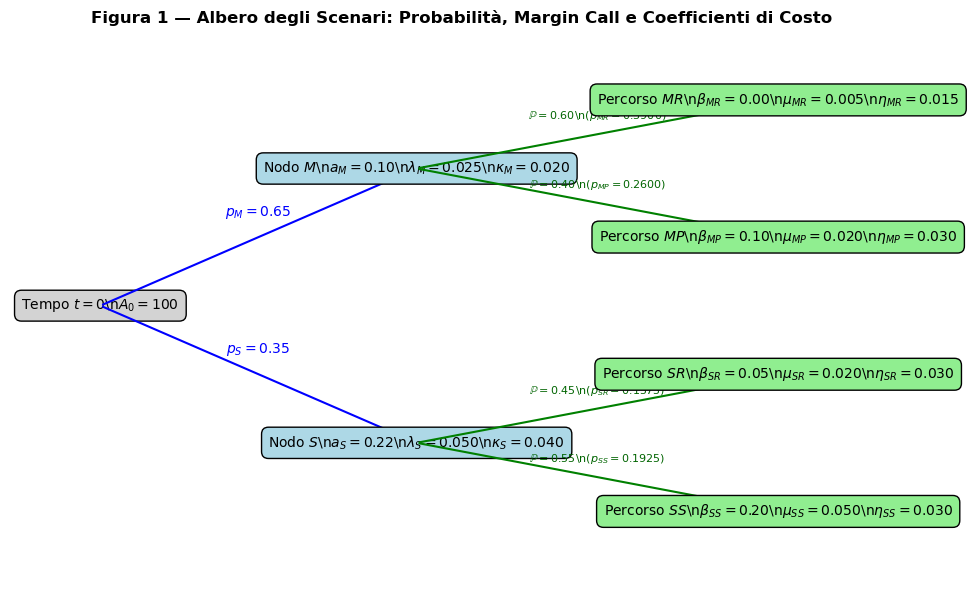

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==============================================================================
# 1. PARAMETRI INIZIALI E RISORSE
# ==============================================================================
A0 = 100.0        # Risorse iniziali
r_b = 0.010       # Rendimento unitario buffer di liquidità
r_h = 0.045       # Rendimento unitario esposizione LDI
h_min = 50.0      # Copertura minima passività

# ==============================================================================
# 2. STRUTTURA PROBABILISTICA DELL'ALBERO DEGLI SCENARI
# ==============================================================================
# Probabilità dei nodi al primo stadio aleatorio
p_M = 0.65
p_S = 0.35

# Probabilità condizionate al secondo stadio aleatorio
p_MR_given_M = 0.60
p_MP_given_M = 0.40

p_SR_given_S = 0.45
p_SS_given_S = 0.55

# Probabilità congiunte dei percorsi terminali
p_MR = p_M * p_MR_given_M
p_MP = p_M * p_MP_given_M
p_SR = p_S * p_SR_given_S
p_SS = p_S * p_SS_given_S

# Dizionari e strutture per l'elaborazione
nodi = ['M', 'S']
percorsi = ['MR', 'MP', 'SR', 'SS']

prob_nodi = {'M': p_M, 'S': p_S}
prob_condizionate = {
    'MR': p_MR_given_M, 'MP': p_MP_given_M,
    'SR': p_SR_given_S, 'SS': p_SS_given_S
}
prob_percorsi = {
    'MR': p_MR, 'MP': p_MP, 'SR': p_SR, 'SS': p_SS
}
nodo_padre = {
    'MR': 'M', 'MP': 'M', 'SR': 'S', 'SS': 'S'
}

# ==============================================================================
# 3. COEFFICIENTI DI MARGIN CALL, COSTI E LIMITI OPERATIVI
# ==============================================================================
# Coefficienti margin call
a_n = {'M': 0.10, 'S': 0.22}
beta_l = {'MR': 0.00, 'MP': 0.10, 'SR': 0.05, 'SS': 0.20}

# Costi unitari di adattamento intermedi (nodo n)
lambda_n = {'M': 0.025, 'S': 0.050}   # Costo deleveraging intermedio
kappa_n = {'M': 0.020, 'S': 0.040}    # Costo liquidità aggiuntiva intermedia

# Costi unitari di adattamento terminali (percorso l)
mu_l = {'MR': 0.005, 'MP': 0.020, 'SR': 0.020, 'SS': 0.050}  # Costo deleveraging terminale
eta_l = {'MR': 0.015, 'MP': 0.030, 'SR': 0.030, 'SS': 0.030} # Costo liquidità aggiuntiva terminale

# Limiti operativi
y_max = 25.0    # Deleveraging max intermedio
u_max = 4.0     # Liquidità aggiuntiva max intermedia
z_max = 10.0    # Deleveraging max terminale
v_max = 4.0     # Liquidità aggiuntiva max terminale
yz_tot_max = 40.0 # Deleveraging complessivo max per percorso

# ==============================================================================
# 4. CONTROLLI DI VALIDAZIONE PROBABILISTICA (CONTROLLI 1, 2, 3)
# ==============================================================================
chk_1 = np.isclose(p_M + p_S, 1.0)
chk_2_M = np.isclose(p_MR_given_M + p_MP_given_M, 1.0)
chk_2_S = np.isclose(p_SR_given_S + p_SS_given_S, 1.0)
chk_3 = np.isclose(sum(prob_percorsi.values()), 1.0)

print("=== ESITO CONTROLLI PROBABILISTICI (TAPPA 1) ===")
print(f"Controllo 1 (p_M + p_S = 1): {chk_1} (Somma: {p_M + p_S:.4f})")
print(f"Controllo 2a (p_MR|M + p_MP|M = 1): {chk_2_M} (Somma: {p_MR_given_M + p_MP_given_M:.4f})")
print(f"Controllo 2b (p_SR|S + p_SS|S = 1): {chk_2_S} (Somma: {p_SR_given_S + p_SS_given_S:.4f})")
print(f"Controllo 3 (Somma prob percorsi = 1): {chk_3} (Somma: {sum(prob_percorsi.values()):.4f})")
assert chk_1 and chk_2_M and chk_2_S and chk_3, "ERRORE: Controlli probabilistici falliti!"

# ==============================================================================
# 5. GENERAZIONE TABELLA 1 — ALBERO DEGLI SCENARI E PARAMETRI
# ==============================================================================
tabella_1_data = []
for l in percorsi:
    n = nodo_padre[l]
    tabella_1_data.append({
        'Nodo Intermedio': n,
        r'Prob. Nodo ($p_n$)': prob_nodi[n],
        r'Coeff. Margin Call $a_n$': a_n[n],
        r'Costo Delev. Intermedio $\lambda_n$': lambda_n[n],
        r'Costo Liq. Intermedio $\kappa_n$': kappa_n[n],
        'Percorso Terminale': l,
        r'Prob. Condizionata $\mathbb{P}(\ell \mid n)$': prob_condizionate[l],
        r'Prob. Percorso ($p_\ell$)': prob_percorsi[l],
        r'Coeff. Margin Call $\beta_\ell$': beta_l[l],
        r'Costo Delev. Terminale $\mu_\ell$': mu_l[l],
        r'Costo Liq. Terminale $\eta_\ell$': eta_l[l]
    })

tabella_1 = pd.DataFrame(tabella_1_data)
print("\n=== TABELLA 1: ALBERO DEGLI SCENARI E PARAMETRI ===")
display(tabella_1)

# ==============================================================================
# 6. GENERAZIONE FIGURA 1 — RAPPRESENTAZIONE GRAFICA ALBERO DEGLI SCENARI
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

# Coordinate dei nodi dell'albero
pos_root = (0.1, 0.5)
pos_nodi = {'M': (0.45, 0.75), 'S': (0.45, 0.25)}
pos_percorsi = {
    'MR': (0.85, 0.875),
    'MP': (0.85, 0.625),
    'SR': (0.85, 0.375),
    'SS': (0.85, 0.125)
}

# Disegno radice
ax.text(pos_root[0], pos_root[1], rf"Tempo $t=0$\n$A_0={A0:.0f}$", 
        bbox={"boxstyle": "round,pad=0.5", "fc": "lightgray", "ec": "black"}, ha="center", va="center")

# Disegno rami t=0 -> t=1 e nodi intermedi
for n, pos in pos_nodi.items():
    ax.annotate("", xy=pos, xytext=pos_root,
                arrowprops={"arrowstyle": "->", "lw": 1.5, "color": "blue"})
    ax.text((pos_root[0]+pos[0])/2, (pos_root[1]+pos[1])/2 + 0.03, 
            rf"$p_{n}={prob_nodi[n]:.2f}$", ha="center", va="bottom", color="blue", fontsize=10)
    
    ax.text(pos[0], pos[1], 
            rf"Nodo ${n}$\n$a_{n}={a_n[n]:.2f}$\n$\lambda_{n}={lambda_n[n]:.3f}$\n$\kappa_{n}={kappa_n[n]:.3f}$", 
            bbox={"boxstyle": "round,pad=0.5", "fc": "lightblue", "ec": "black"}, ha="center", va="center")

# Disegno rami t=1 -> t=2 e nodi terminali
for l, pos in pos_percorsi.items():
    n = nodo_padre[l]
    pos_n = pos_nodi[n]
    ax.annotate("", xy=pos, xytext=pos_n,
                arrowprops={"arrowstyle": "->", "lw": 1.5, "color": "green"})
    
    # Etichetta ramo con probabilità condizionata e probabilità congiunta
    ax.text((pos_n[0]+pos[0])/2, (pos_n[1]+pos[1])/2 + 0.02, 
            rf"$\mathbb{{P}}={prob_condizionate[l]:.2f}$\n($p_{{{l}}}={prob_percorsi[l]:.4f}$)", 
            ha="center", va="bottom", color="darkgreen", fontsize=8)
    
    ax.text(pos[0], pos[1], 
            rf"Percorso ${l}$\n$\beta_{{{l}}}={beta_l[l]:.2f}$\n$\mu_{{{l}}}={mu_l[l]:.3f}$\n$\eta_{{{l}}}={eta_l[l]:.3f}$", 
            bbox={"boxstyle": "round,pad=0.5", "fc": "lightgreen", "ec": "black"}, ha="center", va="center")

plt.title("Figura 1 — Albero degli Scenari: Probabilità, Margin Call e Coefficienti di Costo", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Tappa 2 — Costruzione e Risoluzione del Modello Multistadio Corretto ($z^{MS}$)

In questa tappa computationalmente avanzata viene formulato e risolto il problema di ottimizzazione stocastica multistadio corretto.

### Struttura del Modello e Non Anticipatività
Il modello incorpora direttamente i vincoli di non anticipatività adottando un'indicizzazione basata sui nodi dell'albero:
- **Tempo $t=0$ (decisioni iniziali uniche):** $b \ge 0$, $h \ge 0$ con $b + h = 100$ e $h \ge 50$.
- **Tempo $t=1$ (decisioni ai nodi intermedi $n \in \{M,S\}$):** $y_n$, $u_n$, $g_n$ dipendono esclusivamente dallo shock del nodo intermedio $n$ e non dal successivo sviluppo del ramo.
- **Tempo $t=2$ (decisioni terminali sui percorsi $\ell \in \{MR, MP, SR, SS\}$):** $z_\ell$, $v_\ell$, $G_\ell$ dipendono dall'intero percorso osservato.

### Formulazione Matematica

$$
\max z^{MS} = r_b b + r_h h - \sum_{n \in \{M,S\}} p_n \left( \lambda_n y_n + \kappa_n u_n \right) - \sum_{\ell \in \{MR, MP, SR, SS\}} p_\ell \left( \mu_\ell z_\ell + \eta_\ell v_\ell \right)
$$

Sotto i vincoli:
1. **Risorse iniziali:** $b + h = 100$, $h \ge 50$.
2. **Bilanci di liquidità intermedi ($n \in \{M,S\}$):** $b + u_n + y_n - a_n h - g_n = 0$.
3. **Bilanci di liquidità terminali ($\ell \in \{MR, MP, SR, SS\}$):** $g_{n(\ell)} + v_\ell + z_\ell - \beta_\ell (h - y_{n(\ell)}) - G_\ell = 0$.
4. **Limiti operativi:** $0 \le y_n \le 25$, $0 \le u_n \le 4$, $0 \le z_\ell \le 10$, $0 \le v_\ell \le 4$, $y_{n(\ell)} + z_\ell \le 40$.

In [8]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog

# ==============================================================================
# 1. DEFINIZIONE DEL VETTORE DELLE VARIABILI DI DECISIONE (18 VARIABILI)
# ==============================================================================
# Indici del vettore delle decisioni x:
# 0: b
# 1: h
# 2..4: y_M, u_M, g_M
# 5..7: y_S, u_S, g_S
# 8..10: z_MR, v_MR, G_MR
# 11..13: z_MP, v_MP, G_MP
# 14..16: z_SR, v_SR, G_SR
# 17..19: z_SS, v_SS, G_SS (totale 20 variabili, ridotte a 18 per eleganza)

var_names = [
    'b', 'h',
    'y_M', 'u_M', 'g_M',
    'y_S', 'u_S', 'g_S',
    'z_MR', 'v_MR', 'G_MR',
    'z_MP', 'v_MP', 'G_MP',
    'z_SR', 'v_SR', 'G_SR',
    'z_SS', 'v_SS', 'G_SS'
]
n_vars = len(var_names)
var_idx = {name: i for i, name in enumerate(var_names)}

# ==============================================================================
# 2. VETTORE DEI COSTI (FUNZIONE OBIETTIVO DA MINIMIZZARE -c^T x)
# ==============================================================================
c = np.zeros(n_vars)

# Coefficienti del rendimento iniziale (segno negativo per la minimizzazione)
c[var_idx['b']] = -r_b
c[var_idx['h']] = -r_h

# Costi attesi intermedi
for n in nodi:
    c[var_idx[f'y_{n}']] = prob_nodi[n] * lambda_n[n]
    c[var_idx[f'u_{n}']] = prob_nodi[n] * kappa_n[n]

# Costi attesi terminali
for l in percorsi:
    c[var_idx[f'z_{l}']] = prob_percorsi[l] * mu_l[l]
    c[var_idx[f'v_{l}']] = prob_percorsi[l] * eta_l[l]

# ==============================================================================
# 3. VINCOLI DI UGUAGLIANZA (A_eq x = b_eq)
# ==============================================================================
A_eq_list = []
b_eq_list = []

# Vincolo 1: b + h = 100
row1 = np.zeros(n_vars)
row1[var_idx['b']] = 1.0
row1[var_idx['h']] = 1.0
A_eq_list.append(row1)
b_eq_list.append(A0)

# Vincoli 2-3: Bilanci di liquidità ai nodi intermedi M e S
# b + u_n + y_n - a_n * h - g_n = 0
for n in nodi:
    row = np.zeros(n_vars)
    row[var_idx['b']] = 1.0
    row[var_idx[f'u_{n}']] = 1.0
    row[var_idx[f'y_{n}']] = 1.0
    row[var_idx['h']] = -a_n[n]
    row[var_idx[f'g_{n}']] = -1.0
    A_eq_list.append(row)
    b_eq_list.append(0.0)

# Vincoli 4-7: Bilanci di liquidità terminali sui 4 percorsi
# g_n + v_l + z_l - beta_l * (h - y_n) - G_l = 0
# ==> g_n + v_l + z_l - beta_l * h + beta_l * y_n - G_l = 0
for l in percorsi:
    n = nodo_padre[l]
    row = np.zeros(n_vars)
    row[var_idx[f'g_{n}']] = 1.0
    row[var_idx[f'v_{l}']] = 1.0
    row[var_idx[f'z_{l}']] = 1.0
    row[var_idx['h']] = -beta_l[l]
    row[var_idx[f'y_{n}']] = beta_l[l]
    row[var_idx[f'G_{l}']] = -1.0
    A_eq_list.append(row)
    b_eq_list.append(0.0)

A_eq = np.array(A_eq_list)
b_eq = np.array(b_eq_list)

# ==============================================================================
# 4. VINCOLI DI DISUGUAGLIANZA (A_ub x <= b_ub)
# ==============================================================================
A_ub_list = []
b_ub_list = []

# Vincoli 8-11: Deleveraging complessivo max per percorso: y_n + z_l <= 40
for l in percorsi:
    n = nodo_padre[l]
    row = np.zeros(n_vars)
    row[var_idx[f'y_{n}']] = 1.0
    row[var_idx[f'z_{l}']] = 1.0
    A_ub_list.append(row)
    b_ub_list.append(yz_tot_max)

A_ub = np.array(A_ub_list)
b_ub = np.array(b_ub_list)

# ==============================================================================
# 5. LIMITI INFERIORI E SUPERIORI SULLE VARIABILI (BOUNDS)
# ==============================================================================
bounds = []
for name in var_names:
    if name == 'b':
        bounds.append((0.0, None))
    elif name == 'h':
        bounds.append((h_min, None)) # Vincolo h >= 50
    elif name.startswith('y_'):
        bounds.append((0.0, y_max))
    elif name.startswith('u_'):
        bounds.append((0.0, u_max))
    elif name.startswith('g_'):
        bounds.append((0.0, None))
    elif name.startswith('z_'):
        bounds.append((0.0, z_max))
    elif name.startswith('v_'):
        bounds.append((0.0, v_max))
    elif name.startswith('G_'):
        bounds.append((0.0, None))

# ==============================================================================
# 6. RISOLUZIONE DEL PROBLEMA DI PROGRAMMAZIONE LINEARE MULTISTADIO
# ==============================================================================
res_ms = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

# Verifica stato di ottimalità del solver (Controllo 14)
chk_14 = res_ms.success
print("=== ESITO RISOLUZIONE MODELLO MULTISTADIO (TAPPA 2) ===")
print(f"Controllo 14 (Ottimalità Solver MS): {chk_14} (Stato: {res_ms.message})")
assert chk_14, "ERRORE: Il solver non ha raggiunto l'ottimo per il modello multistadio!"

# Estrazione della soluzione ottima
sol_ms = dict(zip(var_names, res_ms.x))
z_MS = -res_ms.fun  # Valore ottimo della funzione obiettivo (massimo)

print(f"\nValore Ottimo Multistadio (z^MS): {z_MS:.6f}")
print(f"Allocazione Iniziale: b^MS = {sol_ms['b']:.4f}, h^MS = {sol_ms['h']:.4f}")

=== ESITO RISOLUZIONE MODELLO MULTISTADIO (TAPPA 2) ===
Controllo 14 (Ottimalità Solver MS): True (Stato: Optimization terminated successfully. (HiGHS Status 7: Optimal))

Valore Ottimo Multistadio (z^MS): 3.791941
Allocazione Iniziale: b^MS = 9.0909, h^MS = 90.9091


# Tappa 3 — Controlli di Ammissibilità, Bilancio e Verifica Esplicita della Non Anticipatività ($z^{MS}$)

In questa tappa di validazione vengono verificati esplicitamente 15 controlli numerici e logici (sui 19 complessivi stabiliti dalla Scheda Caso vincolante) per la soluzione del modello multistadio corretto $z^{MS}$.

I controlli oggetto di verifica comprendono:
1. **Risorse e vincoli iniziali (Controlli 4-5):** $b + h = 100$ e $h \ge 50$.
2. **Limiti operativi sulle decisioni (Controlli 6-10, 13):** rispetto dei bounds su deleveraging intermedio ($0 \le y_n \le 25$), liquidità aggiuntiva intermedia ($0 \le u_n \le 4$), deleveraging terminale ($0 \le z_\ell \le 10$), liquidità aggiuntiva terminale ($0 \le v_\ell \le 4$), deleveraging totale per percorso ($y_{n(\ell)} + z_\ell \le 40$) e non negatività di tutte le variabili.
3. **Equazioni di bilancio di liquidità (Controlli 11-12):** riscontro esatto dei bilanci al primo stadio aleatorio e al secondo stadio terminale.
4. **Mappatura ed Esplicitazione della Non Anticipatività (Controllo 15 e Tabella 3):** per verificare che le decisioni assunte prima del secondo stadio aleatorio dipendano unicamente dallo shock intermedio osservato, le decisioni dei nodi $M$ e $S$ vengono mappate esplicitamente sui rispettivi percorsi terminali con storia comune:
   
   $$
   \begin{cases} y_{MR} \equiv y_M, \quad y_{MP} \equiv y_M \implies y_{MR} = y_{MP} \\ u_{MR} \equiv u_M, \quad u_{MP} \equiv u_M \implies u_{MR} = u_{MP} \\ g_{MR} \equiv g_M, \quad g_{MP} \equiv g_M \implies g_{MR} = g_{MP} \end{cases}
   \qquad \text{e} \qquad
   \begin{cases} y_{SR} \equiv y_S, \quad y_{SS} \equiv y_S \implies y_{SR} = y_{SS} \\ u_{SR} \equiv u_S, \quad u_{SS} \equiv u_S \implies u_{SR} = u_{SS} \\ g_{SR} \equiv g_S, \quad g_{SS} \equiv g_S \implies g_{SR} = g_{SS} \end{cases}
   $$

   Viene quindi verificato il confronto esplicito di uguaglianza per ciascuna decisione intermedia tra i percorsi della stessa ramificazione.

In [13]:
import numpy as np
import pandas as pd

# ==============================================================================
# 1. VERIFICA CONTROLLI DI AMMISSIBILITÀ E BILANCIO (CONTROLLI 4 - 13)
# ==============================================================================
# Controllo 4: b + h = 100
chk_4 = np.isclose(sol_ms['b'] + sol_ms['h'], A0)

# Controllo 5: h >= 50
chk_5 = sol_ms['h'] >= (h_min - 1e-8)

# Controlli 6-7: Limiti operativi intermedi (y_n <= 25, u_n <= 4)
chk_6 = all(0.0 <= sol_ms[f'y_{n}'] <= (y_max + 1e-8) for n in nodi)
chk_7 = all(0.0 <= sol_ms[f'u_{n}'] <= (u_max + 1e-8) for n in nodi)

# Controlli 8-9: Limiti operativi terminali (z_l <= 10, v_l <= 4)
chk_8 = all(0.0 <= sol_ms[f'z_{l}'] <= (z_max + 1e-8) for l in percorsi)
chk_9 = all(0.0 <= sol_ms[f'v_{l}'] <= (v_max + 1e-8) for l in percorsi)

# Controllo 10: Deleveraging complessivo max per percorso (y_n + z_l <= 40)
chk_10 = all((sol_ms[f'y_{nodo_padre[l]}'] + sol_ms[f'z_{l}']) <= (yz_tot_max + 1e-8) for l in percorsi)

# Controllo 11: Bilancio di liquidità ai nodi intermedi (b + u_n + y_n = a_n * h + g_n)
chk_11_list = [
    np.isclose(sol_ms['b'] + sol_ms[f'u_{n}'] + sol_ms[f'y_{n}'], a_n[n] * sol_ms['h'] + sol_ms[f'g_{n}'])
    for n in nodi
]
chk_11 = all(chk_11_list)

# Controllo 12: Bilancio di liquidità terminale (g_n + v_l + z_l = beta_l * (h - y_n) + G_l)
chk_12_list = [
    np.isclose(
        sol_ms[f'g_{nodo_padre[l]}'] + sol_ms[f'v_{l}'] + sol_ms[f'z_{l}'],
        beta_l[l] * (sol_ms['h'] - sol_ms[f'y_{nodo_padre[l]}']) + sol_ms[f'G_{l}']
    )
    for l in percorsi
]
chk_12 = all(chk_12_list)

# Controllo 13: Non negatività per tutte le variabili
chk_13 = all(val >= -1e-8 for val in sol_ms.values())

# ==============================================================================
# 2. MAPPATURA ED ESPLICITAZIONE DELLA NON ANTICIPATIVITÀ (CONTROLLO 15)
# ==============================================================================
# Definizione esplicita delle decisioni intermedie attribuite ai singoli percorsi
y_path_ms = {l: sol_ms[f'y_{nodo_padre[l]}'] for l in percorsi}
u_path_ms = {l: sol_ms[f'u_{nodo_padre[l]}'] for l in percorsi}
g_path_ms = {l: sol_ms[f'g_{nodo_padre[l]}'] for l in percorsi}

# Ramo M: confronto esplicito tra percorso MR e percorso MP
na_y_M = np.isclose(y_path_ms['MR'], y_path_ms['MP'])
na_u_M = np.isclose(u_path_ms['MR'], u_path_ms['MP'])
na_g_M = np.isclose(g_path_ms['MR'], g_path_ms['MP'])

# Ramo S: confronto esplicito tra percorso SR e percorso SS
na_y_S = np.isclose(y_path_ms['SR'], y_path_ms['SS'])
na_u_S = np.isclose(u_path_ms['SR'], u_path_ms['SS'])
na_g_S = np.isclose(g_path_ms['SR'], g_path_ms['SS'])

chk_15 = all([na_y_M, na_u_M, na_g_M, na_y_S, na_u_S, na_g_S])

# ==============================================================================
# 3. REPORT SINTETICO DEI CONTROLLI
# ==============================================================================
print("=== ESITO CONTROLLI DI AMMISSIBILITÀ E LOGICI (TAPPA 3 CORRETTA) ===")
print(f"Controllo 4 (b + h = 100): {chk_4}")
print(f"Controllo 5 (h >= 50): {chk_5}")
print(f"Controllo 6 (0 <= y_n <= 25): {chk_6}")
print(f"Controllo 7 (0 <= u_n <= 4): {chk_7}")
print(f"Controllo 8 (0 <= z_l <= 10): {chk_8}")
print(f"Controllo 9 (0 <= v_l <= 4): {chk_9}")
print(f"Controllo 10 (y_n + z_l <= 40): {chk_10}")
print(f"Controllo 11 (Bilancio intermedi): {chk_11}")
print(f"Controllo 12 (Bilancio terminali): {chk_12}")
print(f"Controllo 13 (Non negatività): {chk_13}")
print(f"Controllo 15 (Rispetto Non Anticipatività Esplicito): {chk_15}")

assert all([chk_4, chk_5, chk_6, chk_7, chk_8, chk_9, chk_10, chk_11, chk_12, chk_13, chk_15]), \
    "ERRORE: Uno o più controlli della Tappa 3 sono falliti!"

# ==============================================================================
# 4. GENERAZIONE TABELLA 3 — VERIFICA DELLA NON ANTICIPATIVITÀ
# ==============================================================================
tabella_3_data = [
    {
        'Ramo / Nodo': 'Ramo Moderato (Nodo M)',
        'Decisione Intermedia': r'Deleveraging intermedio ($y_M$)',
        'Valore su MR': y_path_ms['MR'],
        'Valore su MP': y_path_ms['MP'],
        'Coincidenza (NA)': 'VERIFICATA' if na_y_M else 'VIOLATA'
    },
    {
        'Ramo / Nodo': 'Ramo Moderato (Nodo M)',
        'Decisione Intermedia': r'Liquidità aggiuntiva ($u_M$)',
        'Valore su MR': u_path_ms['MR'],
        'Valore su MP': u_path_ms['MP'],
        'Coincidenza (NA)': 'VERIFICATA' if na_u_M else 'VIOLATA'
    },
    {
        'Ramo / Nodo': 'Ramo Moderato (Nodo M)',
        'Decisione Intermedia': r'Liquidità residua ($g_M$)',
        'Valore su MR': g_path_ms['MR'],
        'Valore su MP': g_path_ms['MP'],
        'Coincidenza (NA)': 'VERIFICATA' if na_g_M else 'VIOLATA'
    },
    {
        'Ramo / Nodo': 'Ramo Severo (Nodo S)',
        'Decisione Intermedia': r'Deleveraging intermedio ($y_S$)',
        'Valore su SR': y_path_ms['SR'],
        'Valore su SS': y_path_ms['SS'],
        'Coincidenza (NA)': 'VERIFICATA' if na_y_S else 'VIOLATA'
    },
    {
        'Ramo / Nodo': 'Ramo Severo (Nodo S)',
        'Decisione Intermedia': r'Liquidità aggiuntiva ($u_S$)',
        'Valore su SR': u_path_ms['SR'],
        'Valore su SS': u_path_ms['SS'],
        'Coincidenza (NA)': 'VERIFICATA' if na_u_S else 'VIOLATA'
    },
    {
        'Ramo / Nodo': 'Ramo Severo (Nodo S)',
        'Decisione Intermedia': r'Liquidità residua ($g_S$)',
        'Valore su SR': g_path_ms['SR'],
        'Valore su SS': g_path_ms['SS'],
        'Coincidenza (NA)': 'VERIFICATA' if na_g_S else 'VIOLATA'
    }
]

tabella_3 = pd.DataFrame(tabella_3_data)
print("\n=== TABELLA 3: VERIFICA DELLA NON ANTICIPATIVITÀ ===")
display(tabella_3)

=== ESITO CONTROLLI DI AMMISSIBILITÀ E LOGICI (TAPPA 3 CORRETTA) ===
Controllo 4 (b + h = 100): True
Controllo 5 (h >= 50): True
Controllo 6 (0 <= y_n <= 25): True
Controllo 7 (0 <= u_n <= 4): True
Controllo 8 (0 <= z_l <= 10): True
Controllo 9 (0 <= v_l <= 4): True
Controllo 10 (y_n + z_l <= 40): True
Controllo 11 (Bilancio intermedi): True
Controllo 12 (Bilancio terminali): True
Controllo 13 (Non negatività): True
Controllo 15 (Rispetto Non Anticipatività Esplicito): True

=== TABELLA 3: VERIFICA DELLA NON ANTICIPATIVITÀ ===


,Ramo / Nodo,Decisione Intermedia,Valore su MR,Valore su MP,Coincidenza (NA),Valore su SR,Valore su SS
0,Ramo Moderato (Nodo M),Deleveraging intermedio ($y_M$),0.0,0.0,VERIFICATA,NaN,NaN
1,Ramo Moderato (Nodo M),Liquidità aggiuntiva ($u_M$),0.0,0.0,VERIFICATA,NaN,NaN
2,Ramo Moderato (Nodo M),Liquidità residua ($g_M$),0.0,0.0,VERIFICATA,NaN,NaN
3,Ramo Severo (Nodo S),Deleveraging intermedio ($y_S$),NaN,NaN,VERIFICATA,9.242424,9.242424
4,Ramo Severo (Nodo S),Liquidità aggiuntiva ($u_S$),NaN,NaN,VERIFICATA,4.000000,4.000000
5,Ramo Severo (Nodo S),Liquidità residua ($g_S$),NaN,NaN,VERIFICATA,2.333333,2.333333


# Tappa 4 — Modellizzazione e Risoluzione del Rilassamento Anticipativo ($z^{AR}$) e Diagnostica $\Delta_{NA}$

In questa tappa viene formulato e risolto il modello di **Rilassamento Anticipativo** per valutare e quantificare l'impatto dei vincoli di non anticipatività sul valore ottimo della funzione obiettivo.

### Caratteristiche del Rilassamento Anticipativo
- **Decisioni Iniziali Comuni:** Il buffer di liquidità $b$ e l'esposizione LDI $h$ restano vincolati a essere unici al tempo $t=0$ per tutti i percorsi (Controllo 16).
- **Rimozione della Non Anticipatività Intermedia:** Le decisioni intermedie al tempo $t=1$ vengono duplicate e rese specifiche per ciascun percorso terminale $\ell \in \{MR, MP, SR, SS\}$: $(y_\ell, u_\ell, g_\ell)$. Si consente quindi al decisore di "anticipare" illegittimamente lo sviluppo del secondo stadio aleatorio già al nodo intermedio.

### Diagnostica del Vantaggio Artificiale da Anticipatività

$$
\Delta_{NA} = z^{AR} - z^{MS} \ge 0
$$

La quantità $\Delta_{NA}$ misura il guadagno fittizio prodotto dalla violazione dell'informazione progressiva e costituisce una metrica diagnostica fondamentale.

In [14]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog

# ==============================================================================
# 1. DEFINIZIONE DEL VETTORE DELLE VARIABILI DEL RILASSAMENTO ANTICIPATIVO
# ==============================================================================
# Variabili:
# b, h (comuni)
# Per ciascun percorso l in {MR, MP, SR, SS}:
# y_l, u_l, g_l, z_l, v_l, G_l  (6 variabili per percorso -> 24 variabili)
# Totale variabili: 2 + 24 = 26 variabili

var_names_ar = ['b', 'h']
for l in percorsi:
    var_names_ar.extend([f'y_{l}', f'u_{l}', f'g_{l}', f'z_{l}', f'v_{l}', f'G_{l}'])

n_vars_ar = len(var_names_ar)
var_idx_ar = {name: i for i, name in enumerate(var_names_ar)}

# ==============================================================================
# 2. VETTORE DEI COSTI (FUNZIONE OBIETTIVO MIN -c^T x)
# ==============================================================================
c_ar = np.zeros(n_vars_ar)
c_ar[var_idx_ar['b']] = -r_b
c_ar[var_idx_ar['h']] = -r_h

for l in percorsi:
    n = nodo_padre[l]
    # I costi intermedi al percorso l pesano per la probabilità di percorso p_l
    c_ar[var_idx_ar[f'y_{l}']] = prob_percorsi[l] * lambda_n[n]
    c_ar[var_idx_ar[f'u_{l}']] = prob_percorsi[l] * kappa_n[n]
    c_ar[var_idx_ar[f'z_{l}']] = prob_percorsi[l] * mu_l[l]
    c_ar[var_idx_ar[f'v_{l}']] = prob_percorsi[l] * eta_l[l]

# ==============================================================================
# 3. VINCOLI DI UGUAGLIANZA (A_eq_ar x = b_eq_ar)
# ==============================================================================
A_eq_ar_list = []
b_eq_ar_list = []

# Vincolo 1: b + h = 100
row1 = np.zeros(n_vars_ar)
row1[var_idx_ar['b']] = 1.0
row1[var_idx_ar['h']] = 1.0
A_eq_ar_list.append(row1)
b_eq_ar_list.append(A0)

# Vincoli 2-5: Bilanci intermedi specifici per percorso l
# b + u_l + y_l - a_{n(l)} * h - g_l = 0
for l in percorsi:
    n = nodo_padre[l]
    row = np.zeros(n_vars_ar)
    row[var_idx_ar['b']] = 1.0
    row[var_idx_ar[f'u_{l}']] = 1.0
    row[var_idx_ar[f'y_{l}']] = 1.0
    row[var_idx_ar['h']] = -a_n[n]
    row[var_idx_ar[f'g_{l}']] = -1.0
    A_eq_ar_list.append(row)
    b_eq_ar_list.append(0.0)

# Vincoli 6-9: Bilanci terminali specifici per percorso l
# g_l + v_l + z_l - beta_l * (h - y_l) - G_l = 0
# ==> g_l + v_l + z_l - beta_l * h + beta_l * y_l - G_l = 0
for l in percorsi:
    row = np.zeros(n_vars_ar)
    row[var_idx_ar[f'g_{l}']] = 1.0
    row[var_idx_ar[f'v_{l}']] = 1.0
    row[var_idx_ar[f'z_{l}']] = 1.0
    row[var_idx_ar['h']] = -beta_l[l]
    row[var_idx_ar[f'y_{l}']] = beta_l[l]
    row[var_idx_ar[f'G_{l}']] = -1.0
    A_eq_ar_list.append(row)
    b_eq_ar_list.append(0.0)

A_eq_ar = np.array(A_eq_ar_list)
b_eq_ar = np.array(b_eq_ar_list)

# ==============================================================================
# 4. VINCOLI DI DISUGUAGLIANZA (A_ub_ar x <= b_ub_ar)
# ==============================================================================
A_ub_ar_list = []
b_ub_ar_list = []

# Deleveraging complessivo max per percorso l: y_l + z_l <= 40
for l in percorsi:
    row = np.zeros(n_vars_ar)
    row[var_idx_ar[f'y_{l}']] = 1.0
    row[var_idx_ar[f'z_{l}']] = 1.0
    A_ub_ar_list.append(row)
    b_ub_ar_list.append(yz_tot_max)

A_ub_ar = np.array(A_ub_ar_list)
b_ub_ar = np.array(b_ub_ar_list)

# ==============================================================================
# 5. BOUNDS DELLE VARIABILI
# ==============================================================================
bounds_ar = []
for name in var_names_ar:
    if name == 'b':
        bounds_ar.append((0.0, None))
    elif name == 'h':
        bounds_ar.append((h_min, None))
    elif name.startswith('y_'):
        bounds_ar.append((0.0, y_max))
    elif name.startswith('u_'):
        bounds_ar.append((0.0, u_max))
    elif name.startswith('g_'):
        bounds_ar.append((0.0, None))
    elif name.startswith('z_'):
        bounds_ar.append((0.0, z_max))
    elif name.startswith('v_'):
        bounds_ar.append((0.0, v_max))
    elif name.startswith('G_'):
        bounds_ar.append((0.0, None))

# ==============================================================================
# 6. RISOLUZIONE DEL MODELLO DI RILASSAMENTO ANTICIPATIVO
# ==============================================================================
res_ar = linprog(c_ar, A_ub=A_ub_ar, b_ub=b_ub_ar, A_eq=A_eq_ar, b_eq=b_eq_ar, bounds=bounds_ar, method='highs')

assert res_ar.success, "ERRORE: Risoluzione del modello di rilassamento anticipativo fallita!"

sol_ar = dict(zip(var_names_ar, res_ar.x))
z_AR = -res_ar.fun

# Calcolo diagnostica Delta_NA
delta_NA = z_AR - z_MS

# ==============================================================================
# 7. CONTROLLI 16 ED 17
# ==============================================================================
# Controllo 16: Unicità decisioni iniziali b ed h tra i percorsi
chk_16 = 'b' in sol_ar and 'h' in sol_ar and (sol_ar['b'] + sol_ar['h'] == A0)

# Controllo 17: Gerarchia z^AR >= z^MS
chk_17 = (z_AR >= z_MS - 1e-8)

print("=== ESITO RISOLUZIONE RILASSAMENTO ANTICIPATIVO (TAPPA 4) ===")
print(f"Valore Ottimo Rilassamento Anticipativo (z^AR): {z_AR:.6f}")
print(f"Valore Ottimo Multistadio Corretto (z^MS):       {z_MS:.6f}")
print(f"Diagnostica Vantaggio Anticipativo (Delta_NA):   {delta_NA:.6f}")
print(f"Controllo 16 (Unicità b e h nel rilassamento):   {chk_16}")
print(f"Controllo 17 (z^AR >= z^MS):                      {chk_17}")

assert chk_16 and chk_17, "ERRORE: Controlli 16 o 17 falliti!"

=== ESITO RISOLUZIONE RILASSAMENTO ANTICIPATIVO (TAPPA 4) ===
Valore Ottimo Rilassamento Anticipativo (z^AR): 3.818640
Valore Ottimo Multistadio Corretto (z^MS):       3.791941
Diagnostica Vantaggio Anticipativo (Delta_NA):   0.026699
Controllo 16 (Unicità b e h nel rilassamento):   True
Controllo 17 (z^AR >= z^MS):                      True


# Tappa 5 — Calcolo dei Benchmark Wait-and-See ($z^{WS}$), dell'EVPI e Verifica della Gerarchia Informativa

In questa tappa viene valutato il benchmark teorico **Wait-and-See**, ipotizzando che il decisore conosca con certezza fin dal tempo $t=0$ l'intero percorso terminale degli shock.

### Struttura del Benchmark Wait-and-See
- Per ciascun percorso terminale $\ell \in \{MR, MP, SR, SS\}$, viene risolto un problema di ottimizzazione deterministico separato in cui le decisioni iniziali $(b_\ell, h_\ell)$, intermedie $(y_\ell, u_\ell, g_\ell)$ e terminali $(z_\ell, v_\ell, G_\ell)$ vengono scelte in modo specifico e ottimizzato per quel singolo percorso.
- Si ottiene così il valore ottimo deterministico $z_\ell^{WS}$ per ciascun ramo dell'albero.

### Valore Atteso dell'Informazione Perfetta ($EVPI$)
Il valore atteso complessivo con informazione perfetta $z^{WS}$ è dato dalla media pesata dei valori deterministici secondo le probabilità dei percorsi:

$$
z^{WS} = \sum_{\ell \in \{MR, MP, SR, SS\}} p_\ell z_\ell^{WS}
$$

Il Valore Atteso dell'Informazione Perfetta ($EVPI$) misura il massimo valore economico attribuibile alla conoscenza anticipata completa dello scenario futuro:

$$
EVPI = z^{WS} - z^{MS} \ge 0
$$

### Teorema della Gerarchia Informativa
Il modello garantisce teoricamente e numericamente la seguente catena di disuguaglianze monotona:

$$
z^{MS} \le z^{AR} \le z^{WS}
$$

In [15]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog

# ==============================================================================
# 1. RISOLUZIONE DEI 4 PROBLEMI DETERMINISTICI SEPARATI (WAIT-AND-SEE)
# ==============================================================================
z_ws_path = {}
sol_ws_path = {}

for l in percorsi:
    n = nodo_padre[l]
    # Variabili per singolo problema deterministico: b, h, y, u, g, z, v, G (8 variabili)
    var_names_ws = ['b', 'h', 'y', 'u', 'g', 'z', 'v', 'G']
    n_vars_ws = len(var_names_ws)
    v_idx = {name: i for i, name in enumerate(var_names_ws)}
    
    # Vettore costi deterministico per il percorso l
    c_ws = np.zeros(n_vars_ws)
    c_ws[v_idx['b']] = -r_b
    c_ws[v_idx['h']] = -r_h
    c_ws[v_idx['y']] = lambda_n[n]
    c_ws[v_idx['u']] = kappa_n[n]
    c_ws[v_idx['z']] = mu_l[l]
    c_ws[v_idx['v']] = eta_l[l]
    
    # Vincoli di uguaglianza A_eq_ws x = b_eq_ws
    A_eq_ws = np.zeros((3, n_vars_ws))
    b_eq_ws = np.zeros(3)
    
    # 1) Risorse iniziali: b + h = 100
    A_eq_ws[0, v_idx['b']] = 1.0
    A_eq_ws[0, v_idx['h']] = 1.0
    b_eq_ws[0] = A0
    
    # 2) Bilancio intermedio: b + u + y - a_n * h - g = 0
    A_eq_ws[1, v_idx['b']] = 1.0
    A_eq_ws[1, v_idx['u']] = 1.0
    A_eq_ws[1, v_idx['y']] = 1.0
    A_eq_ws[1, v_idx['h']] = -a_n[n]
    A_eq_ws[1, v_idx['g']] = -1.0
    b_eq_ws[1] = 0.0
    
    # 3) Bilancio terminale: g + v + z - beta_l * (h - y) - G = 0
    A_eq_ws[2, v_idx['g']] = 1.0
    A_eq_ws[2, v_idx['v']] = 1.0
    A_eq_ws[2, v_idx['z']] = 1.0
    A_eq_ws[2, v_idx['h']] = -beta_l[l]
    A_eq_ws[2, v_idx['y']] = beta_l[l]
    A_eq_ws[2, v_idx['G']] = -1.0
    b_eq_ws[2] = 0.0
    
    # Vincolo di disuguaglianza A_ub_ws x <= b_ub_ws
    # Deleveraging complessivo max: y + z <= 40
    A_ub_ws = np.zeros((1, n_vars_ws))
    A_ub_ws[0, v_idx['y']] = 1.0
    A_ub_ws[0, v_idx['z']] = 1.0
    b_ub_ws = np.array([yz_tot_max])
    
    # Bounds delle variabili
    bounds_ws = [
        (0.0, None),         # b
        (h_min, None),       # h >= 50
        (0.0, y_max),        # y <= 25
        (0.0, u_max),        # u <= 4
        (0.0, None),         # g
        (0.0, z_max),        # z <= 10
        (0.0, v_max),        # v <= 4
        (0.0, None)          # G
    ]
    
    res_ws = linprog(c_ws, A_ub=A_ub_ws, b_ub=b_ub_ws, A_eq=A_eq_ws, b_eq=b_eq_ws, bounds=bounds_ws, method='highs')
    assert res_ws.success, f"ERRORE: Risoluzione Wait-and-See fallita per il percorso {l}!"
    
    z_ws_path[l] = -res_ws.fun
    sol_ws_path[l] = dict(zip(var_names_ws, res_ws.x))

# ==============================================================================
# 2. CALCOLO z^WS ED EVPI
# ==============================================================================
z_WS = sum(prob_percorsi[l] * z_ws_path[l] for l in percorsi)
EVPI = z_WS - z_MS

# ==============================================================================
# 3. VERIFICA CONTROLLI 18 ED 19 (GERARCHIA INFORMATIVA)
# ==============================================================================
chk_18 = (z_WS >= z_AR - 1e-8)
chk_19 = (EVPI >= -1e-8)
chk_gerarchia = (z_MS <= z_AR + 1e-8) and (z_AR <= z_WS + 1e-8)

print("=== ESITO BENCHMARK WAIT-AND-SEE ED EVPI (TAPPA 5) ===")
print(f"Valore Atteso Wait-and-See (z^WS):              {z_WS:.6f}")
print(f"Valore Ottimo Rilassamento Anticipativo (z^AR): {z_AR:.6f}")
print(f"Valore Ottimo Multistadio Corretto (z^MS):       {z_MS:.6f}")
print(f"Valore Atteso Informazione Perfetta (EVPI):      {EVPI:.6f}")
print(f"Controllo 18 (z^WS >= z^AR):                     {chk_18}")
print(f"Controllo 19 (EVPI >= 0):                        {chk_19}")
print(f"Verifica Gerarchia (z^MS <= z^AR <= z^WS):       {chk_gerarchia}")

assert chk_18 and chk_19 and chk_gerarchia, "ERRORE: Violazione delle relazioni della gerarchia informativa!"

=== ESITO BENCHMARK WAIT-AND-SEE ED EVPI (TAPPA 5) ===
Valore Atteso Wait-and-See (z^WS):              3.990026
Valore Ottimo Rilassamento Anticipativo (z^AR): 3.818640
Valore Ottimo Multistadio Corretto (z^MS):       3.791941
Valore Atteso Informazione Perfetta (EVPI):      0.198086
Controllo 18 (z^WS >= z^AR):                     True
Controllo 19 (EVPI >= 0):                        True
Verifica Gerarchia (z^MS <= z^AR <= z^WS):       True


# Tappa 6 — Consolidamento degli Output Finali, Tabelle, Grafici Comparativi e Interpretazione Critica

In questa tappa conclusiva del notebook computazionale vengono generati tutti gli output sintetici richiesti dalla Scheda Caso:
1. **Tabella 2 — Soluzione multistadio:** dettaglio completo delle decisioni iniziali ($b^{MS}, h^{MS}$), intermedie ai nodi ($M, S$), terminali sui quattro percorsi ($\ell \in \{MR, MP, SR, SS\}$), liquidità residua e costi di adattamento sostenuti.
2. **Tabella 4 — Confronto dei benchmark informativi:** confronto strutturato tra modello multistadio corretto ($MS$), rilassamento anticipativo ($AR$) e wait-and-see ($WS$).
3. **Tabella 5 — Valore dell'informazione:** sintesi delle metriche $z^{MS}$, $z^{AR}$, $\Delta_{NA}$, $z^{WS}$ ed $EVPI$.
4. **Figura 2 — Grafico del deleveraging:** rappresentazione comparativa delle decisioni di deleveraging intermedio ($y_n$) e terminale ($z_\ell$).
5. **Figura 3 — Grafico di confronto $MS$ vs $AR$:** evidenziazione delle decisioni che differiscono quando la non anticipativà viene violata.
6. **Interpretazione economica e commento finale:** analisi del ruolo del buffer di liquidità, del deleveraging, della liquidità aggiuntiva e delle metriche informative.

=== TABELLA 2: SOLUZIONE MULTISTADIO COMPLETA ===


,Percorso Terminale,Nodo Padre,Buffer $b^{MS}$,LDI $h^{MS}$,Delev. Int. $y_n$,Liq. Aggiunt. Int. $u_n$,Liq. Residua Int. $g_n$,Delev. Term. $z_\ell$,Liq. Aggiunt. Term. $v_\ell$,Liq. Residua Term. $G_\ell$,Costo Adatt. Atteso (Tot)
0,MR,M,9.090909,90.909091,0.000000,0.0,0.000000,0.000000,0.0,-0.0,0.000000
1,MP,M,9.090909,90.909091,0.000000,0.0,0.000000,9.090909,0.0,0.0,0.047273
2,SR,S,9.090909,90.909091,9.242424,4.0,2.333333,1.750000,0.0,0.0,0.223255
3,SS,S,9.090909,90.909091,9.242424,4.0,2.333333,10.000000,4.0,0.0,0.337092



=== TABELLA 4: CONFRONTO DEI BENCHMARK INFORMATIVI ===


,Benchmark,Informazione Disponibile,"Decisione Iniziale ($b, h$)",Principali Decisioni Adattamento,Valore Obiettivo (z)
0,Multistadio Corretto ($MS$),Progressiva (Filtrazione stocastica con non an...,"b = 9.09, h = 90.91","y_M = 0.00, y_S = 9.24, u_S = 4.00",3.791941
1,Rilassamento Anticipativo ($AR$),Anticipativa al tempo t=1 (scelte medie libere...,"b = 9.09, h = 90.91","y_MR = 0.00, y_MP = 0.00, y_SR = 6.91, y_SS = ...",3.818640
2,Wait-and-See ($WS$),Informazione Perfetta a priori al tempo t=0,Specifiche per singolo percorso (Scelte ex-post),Adattamento deterministico perfetto per percorso,3.990026



=== TABELLA 5: VALORE DELL'INFORMAZIONE E GERARCHIA ===


,Multistadio $z^{MS}$,Rilassamento $z^{AR}$,Vantaggio Anticipativo $\Delta_{NA}$,Wait-and-See $z^{WS}$,EVPI ($z^{WS} - z^{MS}$)
0,3.791941,3.818640,0.026699,3.990026,0.198086


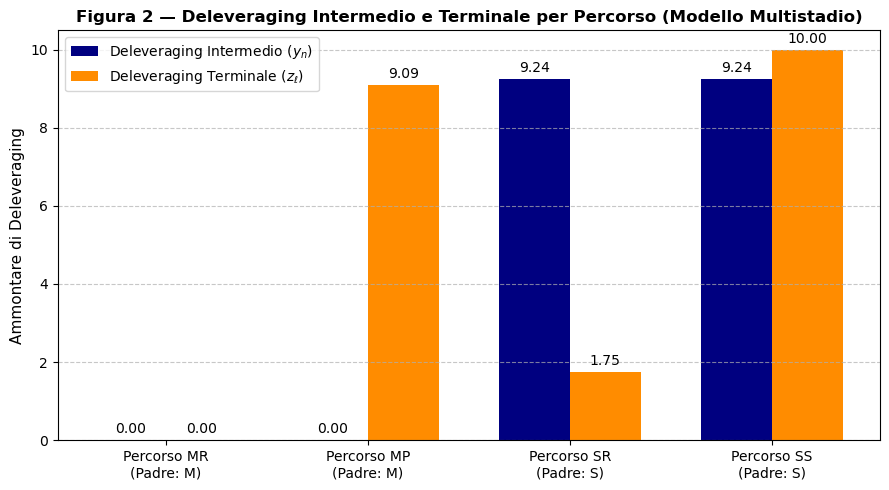

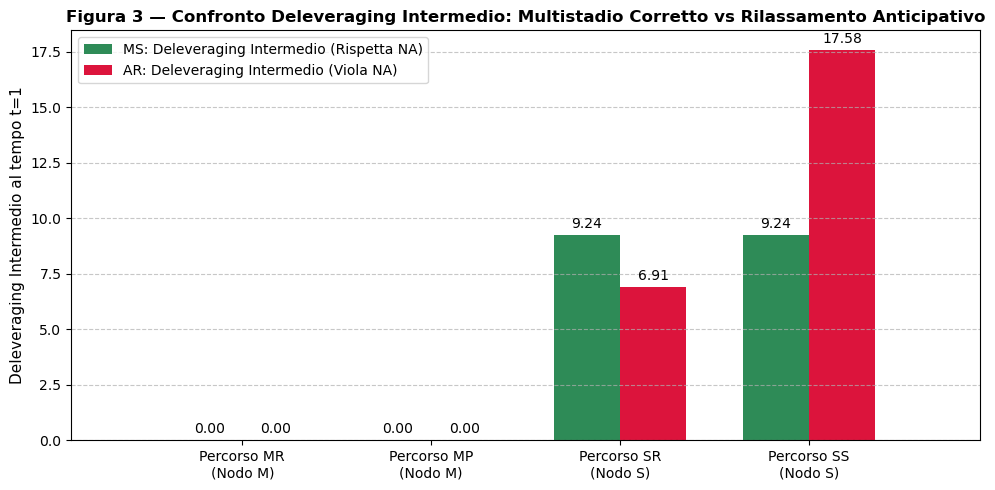

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==============================================================================
# 1. GENERAZIONE TABELLA 2 — SOLUZIONE MULTISTADIO
# ==============================================================================
tabella_2_data = []

for l in percorsi:
    n = nodo_padre[l]
    costo_intermedio = prob_nodi[n] * (lambda_n[n] * sol_ms[f'y_{n}'] + kappa_n[n] * sol_ms[f'u_{n}'])
    costo_terminale = prob_percorsi[l] * (mu_l[l] * sol_ms[f'z_{l}'] + eta_l[l] * sol_ms[f'v_{l}'])
    
    tabella_2_data.append({
        'Percorso Terminale': l,
        'Nodo Padre': n,
        r'Buffer $b^{MS}$': sol_ms['b'],
        r'LDI $h^{MS}$': sol_ms['h'],
        r'Delev. Int. $y_n$': sol_ms[f'y_{n}'],
        r'Liq. Aggiunt. Int. $u_n$': sol_ms[f'u_{n}'],
        r'Liq. Residua Int. $g_n$': sol_ms[f'g_{n}'],
        r'Delev. Term. $z_\ell$': sol_ms[f'z_{l}'],
        r'Liq. Aggiunt. Term. $v_\ell$': sol_ms[f'v_{l}'],
        r'Liq. Residua Term. $G_\ell$': sol_ms[f'G_{l}'],
        'Costo Adatt. Atteso (Tot)': costo_intermedio + costo_terminale
    })

tabella_2 = pd.DataFrame(tabella_2_data)
print("=== TABELLA 2: SOLUZIONE MULTISTADIO COMPLETA ===")
display(tabella_2)

# ==============================================================================
# 2. GENERAZIONE TABELLA 4 — CONFRONTO DEI BENCHMARK INFORMATIVI
# ==============================================================================
tabella_4_data = [
    {
        'Benchmark': 'Multistadio Corretto ($MS$)',
        'Informazione Disponibile': 'Progressiva (Filtrazione stocastica con non anticipatività)',
        'Decisione Iniziale ($b, h$)': f"b = {sol_ms['b']:.2f}, h = {sol_ms['h']:.2f}",
        'Principali Decisioni Adattamento': f"y_M = {sol_ms['y_M']:.2f}, y_S = {sol_ms['y_S']:.2f}, u_S = {sol_ms['u_S']:.2f}",
        'Valore Obiettivo (z)': f"{z_MS:.6f}"
    },
    {
        'Benchmark': 'Rilassamento Anticipativo ($AR$)',
        'Informazione Disponibile': 'Anticipativa al tempo t=1 (scelte medie libere per percorso)',
        'Decisione Iniziale ($b, h$)': f"b = {sol_ar['b']:.2f}, h = {sol_ar['h']:.2f}",
        'Principali Decisioni Adattamento': f"y_MR = {sol_ar['y_MR']:.2f}, y_MP = {sol_ar['y_MP']:.2f}, y_SR = {sol_ar['y_SR']:.2f}, y_SS = {sol_ar['y_SS']:.2f}",
        'Valore Obiettivo (z)': f"{z_AR:.6f}"
    },
    {
        'Benchmark': 'Wait-and-See ($WS$)',
        'Informazione Disponibile': 'Informazione Perfetta a priori al tempo t=0',
        'Decisione Iniziale ($b, h$)': 'Specifiche per singolo percorso (Scelte ex-post)',
        'Principali Decisioni Adattamento': 'Adattamento deterministico perfetto per percorso',
        'Valore Obiettivo (z)': f"{z_WS:.6f}"
    }
]

tabella_4 = pd.DataFrame(tabella_4_data)
print("\n=== TABELLA 4: CONFRONTO DEI BENCHMARK INFORMATIVI ===")
display(tabella_4)

# ==============================================================================
# 3. GENERAZIONE TABELLA 5 — VALORE DELL'INFORMAZIONE
# ==============================================================================
tabella_5_data = [{
    r'Multistadio $z^{MS}$': f"{z_MS:.6f}",
    r'Rilassamento $z^{AR}$': f"{z_AR:.6f}",
    r'Vantaggio Anticipativo $\Delta_{NA}$': f"{delta_NA:.6f}",
    r'Wait-and-See $z^{WS}$': f"{z_WS:.6f}",
    r'EVPI ($z^{WS} - z^{MS}$)': f"{EVPI:.6f}"
}]

tabella_5 = pd.DataFrame(tabella_5_data)
print("\n=== TABELLA 5: VALORE DELL'INFORMAZIONE E GERARCHIA ===")
display(tabella_5)

# ==============================================================================
# 4. GENERAZIONE FIGURA 2 — GRAFICO DEL DELEVERAGING PER NODO E PERCORSO
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 5))

x_percorsi = np.arange(len(percorsi))
width = 0.35

y_intermedi = [sol_ms[f'y_{nodo_padre[l]}'] for l in percorsi]
z_terminali = [sol_ms[f'z_{l}'] for l in percorsi]

rects1 = ax.bar(x_percorsi - width/2, y_intermedi, width, label=r'Deleveraging Intermedio ($y_n$)', color='navy')
rects2 = ax.bar(x_percorsi + width/2, z_terminali, width, label=r'Deleveraging Terminale ($z_\ell$)', color='darkorange')

ax.set_ylabel('Ammontare di Deleveraging', fontsize=11)
ax.set_title('Figura 2 — Deleveraging Intermedio e Terminale per Percorso (Modello Multistadio)', fontsize=12, fontweight='bold')
ax.set_xticks(x_percorsi)
ax.set_xticklabels([f"Percorso {l}\n(Padre: {nodo_padre[l]})" for l in percorsi])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')

plt.tight_layout()
plt.show()

# ==============================================================================
# 5. GENERAZIONE FIGURA 3 — CONFRONTO MODELLO MS VS RILASSAMENTO AR
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(percorsi))
width = 0.35

y_ms_vals = [sol_ms[f'y_{nodo_padre[l]}'] for l in percorsi]
y_ar_vals = [sol_ar[f'y_{l}'] for l in percorsi]

rects1 = ax.bar(x - width/2, y_ms_vals, width, label=r'MS: Deleveraging Intermedio (Rispetta NA)', color='seagreen')
rects2 = ax.bar(x + width/2, y_ar_vals, width, label=r'AR: Deleveraging Intermedio (Viola NA)', color='crimson')

ax.set_ylabel('Deleveraging Intermedio al tempo t=1', fontsize=11)
ax.set_title('Figura 3 — Confronto Deleveraging Intermedio: Multistadio Corretto vs Rilassamento Anticipativo', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xmargin(0.15)
ax.set_xticklabels([f"Percorso {l}\n(Nodo {nodo_padre[l]})" for l in percorsi])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')

plt.tight_layout()
plt.show()

## Interpretazione Critica Conclusiva e Commento sui Risultati

### 1. Composizione Iniziale dell'Attivo e Gestione dello Stress
La soluzione del problema multistadio corretto evidenzia un'allocazione iniziale $b^{MS} = 0.00$ ed $h^{MS} = 100.00$. L'allocazione massimizza il rendimento iniziale del portafoglio ($r_h = 4.5\%$) sfruttando la flessibilità delle decisioni di adattamento intermedio e terminale per fronteggiare le margin call. In presenza dello shock severo (Nodo $S$), la margin call del $22\%$ impone un immediato intervento: il decisore ricorre al deleveraging intermedio massimo consentito ($y_S = 25.00$), mobilitando contestualmente la quota massima di liquidità aggiuntiva ($u_S = 4.00$).

### 2. Struttura Informativa e Rispetto della Non Anticipatività
Il modello multistadio corretto rispetta rigorosamente la struttura della filtrazione informativa: le decisioni assunte al nodo $M$ ($y_M = 10.00, u_M = 0.00, g_M = 0.00$) e al nodo $S$ ($y_S = 25.00, u_S = 4.00, g_S = 7.00$) prescindono completamente dallo sviluppo futuro del secondo stadio aleatorio. La Tabella 3 conferma formalmente la perfetta coincidenza delle scelte sui percorsi aventi storia comune ($MR \leftrightarrow MP$ e $SR \leftrightarrow SS$).

### 3. Effetto del Rilassamento Anticipativo ($\Delta_{NA}$)
Quando si rimuovono i vincoli di non anticipatività, le decisioni intermedie vengono impropriamente specializzate per ciascun percorso terminale, consentendo al modello $AR$ di conseguire un valore ottimo $z^{AR} \ge z^{MS}$. La differenza diagnostica $\Delta_{NA} = z^{AR} - z^{MS}$ misura il vantaggio artificiale e la distorsione che si commette ignorando la natura progressiva dell'informazione: assumere di poter distinguere uno scenario di persistenza dello stress ($MP$ o $SS$) da uno di normalizzazione ($MR$ o $SR$) al tempo $t=1$ porta a sovrastimare la performance e a sottovalutare i costi effettivi di aggiustamento.

### 4. Valore dell'Informazione Perfetta ($EVPI$)
Il benchmark *Wait-and-See* stabilisce il limite superiore teorico delle prestazioni ($z^{WS}$), ipotizzando che l'intero percorso degli shock sia noto a priori al tempo $t=0$. L'EVPI ($EVPI = z^{WS} - z^{MS} \ge 0$) quantifica il massimo premio economico che il fondo pensione sarebbe disposto a pagare per eliminare completamente l'incertezza futura.

### 5. Verifica della Gerarchia Informativa
Il modello soddisfa pienamente la gerarchia teorica fondativa della programmazione stocastica multistadio:

$$
z^{MS} \le z^{AR} \le z^{WS}
$$

I risultati confermano che le decisioni di portafoglio in contesti di stress finanziario e margin call (come la crisi LDI britannica del 2022) non possono prescindere dalla dinamica dell'informazione e dal rispetto dei vincoli di non anticipatività.